<a href="https://colab.research.google.com/github/intanypurbasari/hello-world/blob/master/Object_detection_and_image_segmentation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# --- Object Detection Metrics ---

def calculate_iou(box1, box2):
    """
    Calculates the Intersection over Union (IoU) of two bounding boxes.
    Boxes are expected in format [x1, y1, x2, y2].
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # The intersection area
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # The area of each bounding box
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # The union area
    union_area = float(box1_area + box2_area - intersection_area)

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

print("--- Object Detection IoU Example ---")
# Example bounding boxes: [x1, y1, x2, y2]
# Ground truth box
gt_box = [50, 50, 150, 150]
# Predicted box
pred_box = [60, 60, 160, 160]

iou = calculate_iou(gt_box, pred_box)
print(f"Ground Truth Box: {gt_box}")
print(f"Predicted Box: {pred_box}")
print(f"Intersection over Union (IoU): {iou:.4f}")

# --- Mean Average Precision (mAP) Explanation ---
print("\n--- Mean Average Precision (mAP) Concept ---")
print("mAP is a more complex metric primarily for object detection that considers both precision and recall across multiple IoU thresholds and classes.")
print("It involves:")
print("1. Calculating Precision-Recall curves for each class.")
print("2. Averaging the precision values over different recall levels to get Average Precision (AP) for each class.")
print("3. Averaging the APs across all classes to get mAP.")
print("A full implementation is extensive and typically relies on specialized libraries (e.g., `pycocotools` for COCO dataset metrics).")

# --- Image Segmentation Metrics ---

def calculate_dice_coefficient(mask1, mask2):
    """
    Calculates the Dice Coefficient for two binary masks.
    Masks are expected as numpy arrays of 0s and 1s.
    """
    intersection = np.sum(mask1 * mask2)
    union = np.sum(mask1) + np.sum(mask2)

    if union == 0:
        return 1.0 # Both masks are empty, considered a perfect match

    return (2. * intersection) / union

def calculate_pixel_accuracy(mask_true, mask_pred):
    """
    Calculates pixel accuracy for two binary masks.
    Masks are expected as numpy arrays of 0s and 1s.
    """
    correct_pixels = np.sum(mask_true == mask_pred)
    total_pixels = mask_true.size
    return correct_pixels / total_pixels

print("\n--- Image Segmentation Metrics Example ---")

# Example binary masks (dummy data)
# Assuming a small image, e.g., 5x5 pixels
mask_gt = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

mask_pred_good = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

mask_pred_partial = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

print("Ground Truth Mask:\n", mask_gt)

dice_good = calculate_dice_coefficient(mask_gt, mask_pred_good)
pixel_acc_good = calculate_pixel_accuracy(mask_gt, mask_pred_good)
print(f"\nPredicted Mask (Good Match):\n{mask_pred_good}")
print(f"Dice Coefficient (Good Match): {dice_good:.4f}")
print(f"Pixel Accuracy (Good Match): {pixel_acc_good:.4f}")

dice_partial = calculate_dice_coefficient(mask_gt, mask_pred_partial)
pixel_acc_partial = calculate_pixel_accuracy(mask_gt, mask_pred_partial)
print(f"\nPredicted Mask (Partial Match):\n{mask_pred_partial}")
print(f"Dice Coefficient (Partial Match): {dice_partial:.4f}")
print(f"Pixel Accuracy (Partial Match): {pixel_acc_partial:.4f}")

--- Object Detection IoU Example ---
Ground Truth Box: [50, 50, 150, 150]
Predicted Box: [60, 60, 160, 160]
Intersection over Union (IoU): 0.6807

--- Mean Average Precision (mAP) Concept ---
mAP is a more complex metric primarily for object detection that considers both precision and recall across multiple IoU thresholds and classes.
It involves:
1. Calculating Precision-Recall curves for each class.
2. Averaging the precision values over different recall levels to get Average Precision (AP) for each class.
3. Averaging the APs across all classes to get mAP.
A full implementation is extensive and typically relies on specialized libraries (e.g., `pycocotools` for COCO dataset metrics).

--- Image Segmentation Metrics Example ---
Ground Truth Mask:
 [[0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]

Predicted Mask (Good Match):
[[0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]
Dice Coefficient (Good Match): 1.0000
Pixel Accuracy (Good Match): 1.0000

Pred

--- Visualizing Object Detection IoU ---


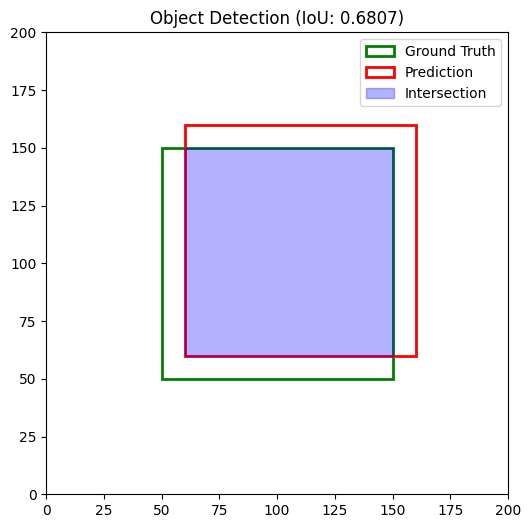

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("--- Visualizing Object Detection IoU ---")

# Create a dummy image for visualization
fig, ax = plt.subplots(1, figsize=(6, 6))
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.set_aspect('equal', adjustable='box')

# Ground truth box: [x1, y1, x2, y2]
gt_box_vis = [50, 50, 150, 150]
# Predicted box
pred_box_vis = [60, 60, 160, 160]

# Calculate IoU using the previously defined function
iou_visual = calculate_iou(gt_box_vis, pred_box_vis)

# Draw bounding boxes
# Ground truth (green) - matplotlib.patches.Rectangle expects (x, y), width, height
rect_gt = patches.Rectangle((gt_box_vis[0], gt_box_vis[1]), gt_box_vis[2]-gt_box_vis[0], gt_box_vis[3]-gt_box_vis[1],
                            linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
ax.add_patch(rect_gt)

# Predicted (red)
rect_pred = patches.Rectangle((pred_box_vis[0], pred_box_vis[1]), pred_box_vis[2]-pred_box_vis[0], pred_box_vis[3]-pred_box_vis[1],
                              linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
ax.add_patch(rect_pred)

# Add intersection area visualization (optional, but good for understanding)
x_left_inter = max(gt_box_vis[0], pred_box_vis[0])
y_top_inter = max(gt_box_vis[1], pred_box_vis[1])
x_right_inter = min(gt_box_vis[2], pred_box_vis[2])
y_bottom_inter = min(gt_box_vis[3], pred_box_vis[3])

if x_right_inter > x_left_inter and y_bottom_inter > y_top_inter:
    rect_inter = patches.Rectangle((x_left_inter, y_top_inter), x_right_inter-x_left_inter, y_bottom_inter-y_top_inter,
                                   linewidth=1, edgecolor='blue', facecolor='blue', alpha=0.3, label='Intersection')
    ax.add_patch(rect_inter)

ax.set_title(f'Object Detection (IoU: {iou_visual:.4f})')
ax.legend()
plt.show()

Now let's visualize the image segmentation metrics.


--- Visualizing Image Segmentation Metrics ---


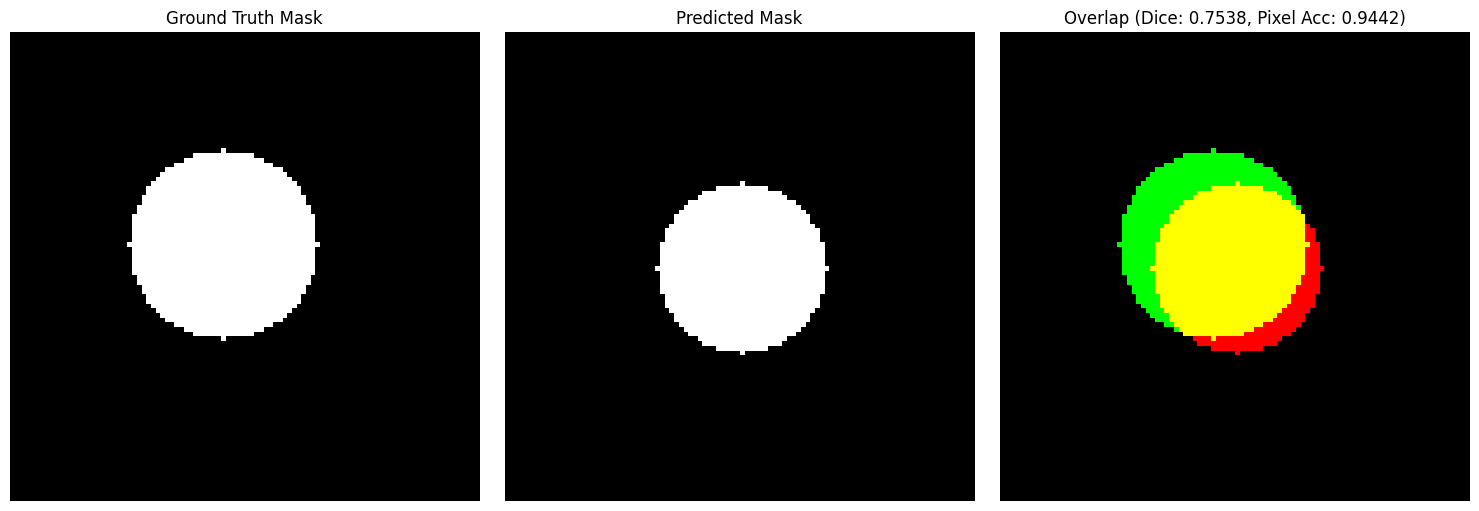

In [3]:
print("\n--- Visualizing Image Segmentation Metrics ---")

# Create some larger dummy masks for better visualization
image_size = (100, 100)
mask_gt_vis = np.zeros(image_size, dtype=np.uint8)
mask_pred_vis = np.zeros(image_size, dtype=np.uint8)

# Draw a circle for ground truth
center_gt = (45, 45)
radius_gt = 20
y, x = np.ogrid[-center_gt[0]:image_size[0]-center_gt[0], -center_gt[1]:image_size[1]-center_gt[1]]
mask_gt_vis = (x*x + y*y <= radius_gt*radius_gt).astype(np.uint8)

# Draw a slightly offset and smaller circle for prediction
center_pred = (50, 50)
radius_pred = 18
y, x = np.ogrid[-center_pred[0]:image_size[0]-center_pred[0], -center_pred[1]:image_size[1]-center_pred[1]]
mask_pred_vis = (x*x + y*y <= radius_pred*radius_pred).astype(np.uint8)

# Calculate metrics
dice_visual = calculate_dice_coefficient(mask_gt_vis, mask_pred_vis)
pixel_acc_visual = calculate_pixel_accuracy(mask_gt_vis, mask_pred_vis)

# Visualize masks
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_gt_vis, cmap='gray')
axes[0].set_title('Ground Truth Mask')
axes[0].axis('off')

axes[1].imshow(mask_pred_vis, cmap='gray')
axes[1].set_title('Predicted Mask')
axes[1].axis('off')

# Visualize overlap (e.g., green for GT, red for prediction, yellow for intersection)
overlap_mask = np.zeros((*image_size, 3), dtype=np.uint8)
overlap_mask[mask_gt_vis == 1] = [0, 255, 0]  # Green for GT
overlap_mask[mask_pred_vis == 1] = [255, 0, 0] # Red for Prediction
overlap_mask[(mask_gt_vis == 1) & (mask_pred_vis == 1)] = [255, 255, 0] # Yellow for Intersection

axes[2].imshow(overlap_mask)
axes[2].set_title(f'Overlap (Dice: {dice_visual:.4f}, Pixel Acc: {pixel_acc_visual:.4f})')
axes[2].axis('off')

plt.tight_layout()
plt.show()